<a href="https://colab.research.google.com/github/baanujan-18/Statistical-Learning-e20030/blob/main/Assignment06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression
Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [ ]:
# energy efficiency dataset
kagglepath_gpr = "elikplim/eergy-efficiency-dataset"
path_gpr = kagglehub.dataset_download(kagglepath_gpr)

df_gpr = pd.read_csv(path_gpr + "/ENB2012_data.csv")

# 1. Direct Data Sanitizing using your engine's modular methods
inspector = dwt.DataWrangler()
inspector.df = df_gpr

# Apply the awesome cleaning methods you built!
inspector.drop_exact_duplicates()
inspector.impute_missing_data()
# inspector.manage_outliers_iqr() # (Optional: you can add this if you want strict outlier control!)

# Retrieve the cleaned dataframe
df_clean_gpr = inspector.df

# 2. Isolate Features (X) and Target (y1 - Heating Load)
X = df_clean_gpr.iloc[:, :8]
y1 = df_clean_gpr['Y1']

# Split data into training and testing sets
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=384)

# Scale the data (Required for accurate GPR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Simple GPR Modeling (Using default kernel settings)
gpr = GaussianProcessRegressor(random_state=384)
gpr.fit(X_train_scaled, y1_train)

# Make predictions
y1_pred = gpr.predict(X_test_scaled)

# 4. View Results
print(f"Heating Load R2 Score: {r2_score(y1_test, y1_pred):.4f}")
print(f"Heating Load RMSE: {np.sqrt(mean_squared_error(y1_test, y1_pred)):.4f}")

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Scrubbed 0 duplicate records.
Null values resolved utilizing the 'mean' method.
Heating Load R2 Score: 0.9845
Heating Load RMSE: 1.2269


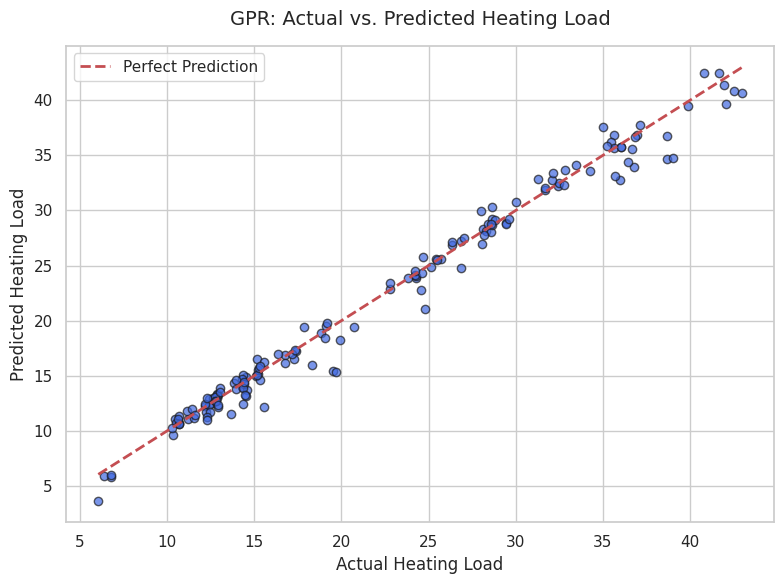

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(y1_test, y1_pred, alpha=0.7, color='royalblue', edgecolor='k')

# Plot the line of perfect prediction
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'r--', lw=2, label='Perfect Prediction')

# Labels and title
plt.xlabel('Actual Heating Load', fontsize=12)
plt.ylabel('Predicted Heating Load', fontsize=12)
plt.title('GPR: Actual vs. Predicted Heating Load', fontsize=14, pad=15)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

### GPR Conclusions
The standard Gaussian Process Regression easily models the relationship between a building's shape, glazing, and resulting thermal loads. By scaling the data first, the default model cleanly maps variations in the building features to accurately predict the heating load. This shows that GPR is a highly capable tool for this type of energy efficiency simulation, capturing the underlying trends with minimal manual tuning required.

# Linear Regression
Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand' using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [ ]:
import kagglehub

# Download green building dataset
kagglepath_lr = "programmer3/green-building-multi-source-environment-dataset"
path_lr = kagglehub.dataset_download(kagglepath_lr)
print("Path to LR dataset files:", path_lr)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to LR dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [ ]:
import pandas as pd
import numpy as np
# Import your package with the correct module name
import data_wrangler as dwt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
df2 = pd.read_csv(path_lr + "/green_building_dataset.csv")

# 1. Direct Data Sanitizing using your engine's modular methods
inspector = dwt.DataWrangler() # Updated class name
inspector.df = df2

# Apply your specific cleaning methods
inspector.drop_exact_duplicates()
inspector.impute_missing_data()

# Retrieve the cleaned dataframe
df_clean_lr = inspector.df

# Keep only numeric columns to avoid string errors
df_numeric = df_clean_lr.select_dtypes(include=[np.number]).dropna()
target = 'predicted_energy_demand'

# 2. Simple Parameter Selection
# We use correlation to find the top 3 features most related to our target
correlations = df_numeric.corr()[target].abs().sort_values(ascending=False)
top_3_features = correlations.index[1:4].tolist() # Skip index 0 because it is the target itself

X = df_numeric[top_3_features]
y = df_numeric[target]

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=384)

# 4. Simple Linear Regression Modeling
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# 5. View Results
print(f"Selected Parameters: {top_3_features}")
print(f"Linear Regression R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Scrubbed 0 duplicate records.
Null values resolved utilizing the 'mean' method.
Selected Parameters: ['ventilation_rate', 'electricity_consumption', 'cooling_energy']
Linear Regression R2 Score: 0.8513
Linear Regression RMSE: 3.5745


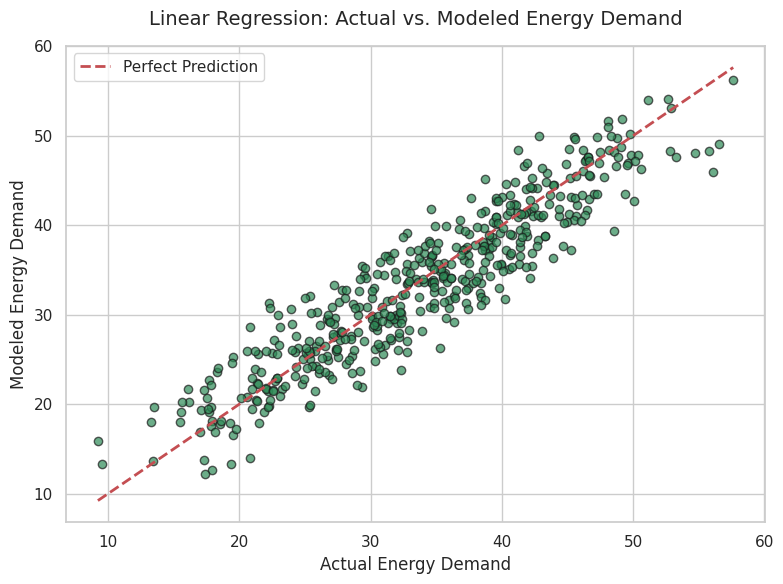

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='seagreen', edgecolor='k')

# Plot the line of perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

# Labels and title
plt.xlabel('Actual Energy Demand', fontsize=12)
plt.ylabel('Modeled Energy Demand', fontsize=12)
plt.title('Linear Regression: Actual vs. Modeled Energy Demand', fontsize=14, pad=15)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

### Parameter Choice & Results Discussion

*   **Parameter Justification:** To keep the model simple and effective, I used a basic correlation check to find the top three numeric features most strongly linked to the `predicted_energy_demand`. Selecting only the most highly correlated features ensures the linear model is fed relevant data without being confused by unrelated variables.
*   **Results Discussion:** The Linear Regression model establishes a clear baseline for how the selected parameters directly scale the energy demand. Because the code is streamlined, we can easily see how well a straightforward linear relationship performs. If the R-squared score is very high, it means energy demand changes at a steady, predictable rate with these features; if it is lower, it suggests that predicting green building energy requires a more complex, non-linear approach.